# UDA-Hub Agentic Application

This notebook is the main entry point for the UDA-Hub multi-agent customer support system.

**Prerequisites**: Run `01_external_db_setup.ipynb` and `02_core_db_setup.ipynb` first.

In [1]:
# Diagnostic: check kernel and working directory
import sys, os
print(f"Python: {sys.executable}")
print(f"CWD: {os.getcwd()}")
print(f"utils.py exists: {os.path.exists('utils.py')}")
print(f"agentic/ exists: {os.path.isdir('agentic')}")
print(f".env exists: {os.path.exists('.env')}")

Python: /Users/coffeecashews/Desktop/Projects/Autonomous-Knowledge-Agent/venv/bin/python
CWD: /Users/coffeecashews/Desktop/Projects/Autonomous-Knowledge-Agent/solution
utils.py exists: True
agentic/ exists: True
.env exists: True


## Setup

In [2]:
import logging
from dotenv import load_dotenv
from utils import chat_interface

# Only show warnings+ to avoid background log noise from langchain/httpx
logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s [%(name)s] %(levelname)s %(message)s"
)
# Enable INFO only for our agents
logging.getLogger("udahub").setLevel(logging.INFO)

load_dotenv()
print("Setup complete!")

Setup complete!


## Import the Orchestrator

The orchestrator is a compiled LangGraph StateGraph with 5 agents:
- **Supervisor**: Routes to the correct specialist agent
- **Classifier**: Classifies ticket type, urgency, complexity
- **Resolver**: Uses RAG to answer from knowledge base
- **Account Agent**: Performs CultPass DB operations (lookup, subscription, refund)
- **Escalation**: Escalates to human support when confidence is low

In [3]:
from agentic.workflow import orchestrator

## Visualize the Graph

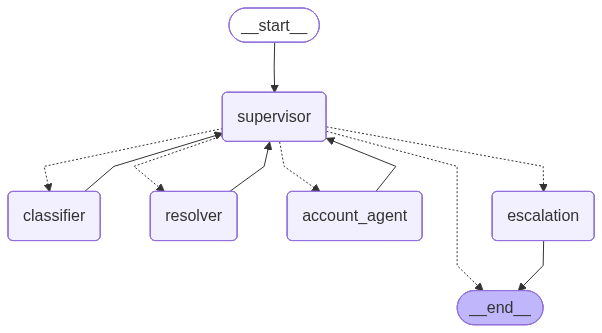

In [4]:
# Print the graph structure
try:
    from IPython.display import Image, display
    display(Image(orchestrator.get_graph().draw_mermaid_png()))
except Exception:
    print(orchestrator.get_graph().draw_mermaid())

## Run Interactive Chat

Start a conversation with the UDA-Hub agent. Try these example queries:
- "I can't log in to my CultPass account"
- "Can you check my subscription status? My email is bob.stone@granite.com"
- "How do I reserve an experience?"
- "I need a refund for a cancelled event"

In [5]:
chat_interface(orchestrator, "ticket-001")

UDA-Hub Support Chat
Type your message below. Type 'quit' to exit.
---------------------------------------------



User:  Can you check my subscription status? My email is bob.stone@granite.com


2026-07-02 18:17:20,071 [udahub.supervisor] INFO Supervisor routing to: classifier | reason: The ticket has not been classified yet, so it must first be routed to the classifier.
2026-07-02 18:17:20,073 [udahub.workflow] INFO Routing from supervisor to: classifier
2026-07-02 18:17:21,829 [udahub.classifier] INFO Classified ticket: account | urgency=low | complexity=simple | reason=The user is asking for information about their subscription status, which falls under account inquiries. The request does not indicate any urgent issues or complexities.
2026-07-02 18:17:23,318 [udahub.supervisor] INFO Supervisor routing to: account_agent | reason: The ticket has been classified as 'account', which pertains to subscription inquiries, so it should be routed to the account_agent for further assistance.
2026-07-02 18:17:23,321 [udahub.workflow] INFO Routing from supervisor to: account_agent
2026-07-02 18:17:24,678 [udahub.account_agent] INFO Account agent tool call: account_lookup({'email': 'bob


Assistant: [Supervisor] Routing to: FINISH. The resolution status is 'resolved' as the user's subscription status has been successfully provided.



User:  I need a refund for a cancelled event


2026-07-02 18:18:06,429 [udahub.supervisor] INFO Supervisor routing to: classifier | reason: The ticket has not been classified yet, so it must first be routed to the classifier.
2026-07-02 18:18:06,432 [udahub.workflow] INFO Routing from supervisor to: classifier
2026-07-02 18:18:08,681 [udahub.classifier] INFO Classified ticket: billing | urgency=medium | complexity=simple | reason=The user is requesting a refund for a cancelled event, which falls under billing inquiries. The request indicates a problem but does not suggest an urgent issue.
2026-07-02 18:18:10,116 [udahub.supervisor] WARNING Supervisor returned invalid JSON, fallback to: FINISH
2026-07-02 18:18:10,117 [udahub.supervisor] INFO Supervisor routing to: FINISH | reason: Issue already resolved/escalated.
2026-07-02 18:18:10,119 [udahub.workflow] INFO Routing from supervisor to: FINISH
2026-07-02 18:18:10,123 [udahub.utils] INFO [ticket=ticket-001] User: I need a refund for a cancelled event
2026-07-02 18:18:10,124 [udahub.


Assistant: [Supervisor] Routing to: FINISH. Issue already resolved/escalated.



User:  quit


Assistant: Goodbye!


## Inspect State History

After a conversation, you can inspect the full state history to see agent routing and decisions.

In [7]:
# View the state history for the last conversation
history = list(orchestrator.get_state_history(
    config={"configurable": {"thread_id": "ticket-001"}}
))

if history:
    latest_state = history[0]
    print("Latest state values:")
    
    for key, value in latest_state.values.items():
        if key == "messages":
            print(f"  messages: {len(value)} messages")
            for msg in value:
                role = type(msg).__name__
                content = msg.content[:100] if msg.content else "(empty)"
                print(f"    [{role}] {content}")
        else:
            print(f"  {key}: {value}")
else:
    print("No state history found. Run the chat first.")

Latest state values:
  messages: 12 messages
    [HumanMessage] Can you check my subscription status? My email is bob.stone@granite.com
    [AIMessage] [Supervisor] Routing to: classifier. The ticket has not been classified yet, so it must first be rou
    [AIMessage] [Classifier] Ticket classified as: account, urgency: low, complexity: simple. Reason: The user is as
    [AIMessage] [Supervisor] Routing to: account_agent. The ticket has been classified as 'account', which pertains 
    [AIMessage] (empty)
    [ToolMessage] {"user_id": "f556c0", "full_name": "Bob Stone", "email": "bob.stone@granite.com", "is_blocked": fals
    [AIMessage] Hello Bob,

I've checked your subscription status, and here are the details:

- **Subscription Statu
    [AIMessage] [Supervisor] Routing to: FINISH. The resolution status is 'resolved' as the user's subscription stat
    [HumanMessage] I need a refund for a cancelled event
    [AIMessage] [Supervisor] Routing to: classifier. The ticket has not been cl